# Growing a marketplace without breaking it

### A study of orders, delivery and customer satisfaction

An online marketplace connects thousands of small sellers to customers spread
across Brazil. The central business question is how to grow while preserving
customer experience: signing up sellers quickly can increase sales, but late
deliveries and poor products may drive customers away. Restricting slow sellers
may improve quality, but can shrink the catalogue and stall growth.

This notebook examines the order data to determine whether that trade-off is
real, and where it occurs.

**Questions addressed**

1. Is growth already costing satisfaction, or is it only a risk?
2. What actually makes someone leave a one-star review?
3. If it's delivery, which part (the seller packing it, or the carrier moving it)?
4. Which categories, regions and sellers carry the most risk?
5. What would each possible fix cost, and what would it buy?

The findings are summarized at the bottom after the supporting analysis.

**Dataset:** 99,441 orders from a Brazilian e-commerce marketplace, spanning
September 2016 to October 2018, split across nine relational tables plus two
marketing tables.


## How to run this

You need the eleven CSV files. Pick whichever is easiest:

- **Upload a zip**: run the next cell and choose your `Project Dataset.zip`
- **Google Drive**: put the CSVs in a Drive folder and set `DATA_DIR` to it
- **Local Jupyter**: put the CSVs in a folder next to this notebook

The loader below tries each in turn, so usually you can just run everything
top to bottom.


In [1]:
# Dependencies. Colab already has all of these, so this is normally a no-op.
import sys, subprocess

for pkg in ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]:
    try:
        __import__(pkg if pkg != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Ready.")



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


Ready.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [3]:
import os, re, glob, zipfile, warnings, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

IN_COLAB = "google.colab" in sys.modules


def find_data():
    """Locate the CSVs, trying the most convenient source first."""
    for guess in [".", "data", "data/raw", "Project Dataset",
                  "/content/data", "/content"]:
        if glob.glob(f"{guess}/**/orders_dataset.csv", recursive=True):
            hit = glob.glob(f"{guess}/**/orders_dataset.csv", recursive=True)[0]
            return str(Path(hit).parent)

    if IN_COLAB:
        from google.colab import files
        print("Upload the dataset zip (or the CSVs directly).")
        up = files.upload()
        for name in up:
            if name.endswith(".zip"):
                with zipfile.ZipFile(name) as z:
                    z.extractall("/content/data")
        hits = glob.glob("/content/**/orders_dataset.csv", recursive=True)
        if hits:
            return str(Path(hits[0]).parent)

    raise FileNotFoundError(
        "Couldn't find orders_dataset.csv. Set DATA_DIR manually below."
    )


DATA_DIR = find_data()          # <- override this line if you know the path
print("Reading from:", DATA_DIR)


Reading from: Project Dataset/E-Commerce Dataset 


In [4]:
# One dict holding every table. Filenames in the archive sometimes carry
# stray spaces, so match on the stem rather than the exact name.
WANTED = ["orders", "order_items", "order_payments", "order_reviews",
          "customers", "sellers", "products", "product_category_name_translation",
          "geolocation", "marketing_qualified_leads", "closed_deals"]

raw = {}
for path in glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True):
    stem = Path(path).stem.strip().replace("_dataset", "")
    if stem in WANTED:
        raw[stem] = pd.read_csv(path)

missing = set(WANTED) - set(raw)
print(f"Loaded {len(raw)} tables." + (f"  MISSING: {missing}" if missing else ""))

for name, df in sorted(raw.items()):
    print(f"  {name:36s} {len(df):>9,} rows  x {df.shape[1]:>2} cols")


Loaded 9 tables.  MISSING: {'marketing_qualified_leads', 'closed_deals'}
  customers                               99,441 rows  x  5 cols
  geolocation                          1,000,163 rows  x  5 cols
  order_items                            112,650 rows  x  7 cols
  order_payments                         103,886 rows  x  5 cols
  order_reviews                           99,224 rows  x  7 cols
  orders                                  99,441 rows  x  8 cols
  product_category_name_translation           71 rows  x  2 cols
  products                                32,951 rows  x  9 cols
  sellers                                  3,095 rows  x  4 cols


## A note on the charts

Styling is fixed once, up front, so colours remain consistent across cells.
Two rules apply throughout:

**Colour means something or it isn't used.** Red is always a bad outcome, green
is always a good one, amber means "look here". Nothing is coloured just to
brighten up a chart. This makes the legend easier to interpret.

**No chart junk.** No 3D, no gradients, no gridlines fighting the data.


In [5]:
NAVY, AMBER, RED, GREEN = "#1f3a68", "#e8833a", "#c1462f", "#2e8b6f"
GREY, LINE = "#8a93a5", "#e6e9ef"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": NAVY,
    "axes.titlepad": 14,
    "axes.labelcolor": "#2b3245",
    "axes.edgecolor": LINE,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": LINE,
    "grid.linewidth": 0.8,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "legend.frameon": False,
    "figure.facecolor": "white",
})
for side in ["top", "right"]:
    plt.rcParams[f"axes.spines.{side}"] = False


def label_bars(ax, fmt="{:.2f}", pad=3):
    """Put the value on top of each bar. Saves the reader squinting at an axis."""
    for p in ax.patches:
        if np.isfinite(p.get_height()):
            ax.annotate(fmt.format(p.get_height()),
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=10,
                        color="#2b3245", xytext=(0, pad),
                        textcoords="offset points")


print("Style set.")


Style set.


# 1. Getting oriented

The first step is to identify how the tables connect and, more importantly,
what the grain of each one is. Getting the grain wrong can double-count revenue
without making the error obvious.


In [6]:
print("orders        :", raw["orders"].order_id.nunique(), "unique ids /",
      len(raw["orders"]), "rows")
print("order_items   :", raw["order_items"].order_id.nunique(), "unique orders /",
      len(raw["order_items"]), "rows")
print("order_reviews :", raw["order_reviews"].order_id.nunique(), "unique orders /",
      len(raw["order_reviews"]), "rows")
print("customers     :", raw["customers"].customer_id.nunique(), "customer_id /",
      raw["customers"].customer_unique_id.nunique(), "customer_unique_id")


orders        : 99441 unique ids / 99441 rows
order_items   : 98666 unique orders / 112650 rows
order_reviews : 98673 unique orders / 99224 rows
customers     : 99441 customer_id / 96096 customer_unique_id


Three things fall out of that, and all three matter later.

**`order_items` has more rows than orders.** An order can contain several items,
possibly from different sellers. So anything at order level needs aggregating
first, and "number of orders" and "number of items" are different questions.

**`order_reviews` has more rows than it has distinct orders.** A few hundred
orders got surveyed twice. A naive join silently duplicates those orders and
weights them double.

**`customer_id` is not a person.** There are as many customer_ids as there are
orders, because a new one is minted per order. `customer_unique_id` is the
actual person. This distinction is essential for repeat-purchase analysis.


In [7]:
dupes = raw["order_reviews"].order_id.duplicated().sum()
print(f"Orders with more than one review: {dupes}")

# Keep the earliest review per order: it's the one reflecting the delivery
# the customer actually just had.
reviews = (raw["order_reviews"]
           .sort_values(["order_id", "review_creation_date"])
           .drop_duplicates("order_id", keep="first"))

print(f"After deduplication: {len(reviews):,} reviews")


Orders with more than one review: 551
After deduplication: 98,673 reviews


# 2. Data quality

Potential problems are identified before analysis: missing values,
contradictions, and physically impossible timestamps.


In [8]:
orders = raw["orders"].copy()
TS = ["order_purchase_timestamp", "order_approved_at",
      "order_delivered_carrier_date", "order_delivered_customer_date",
      "order_estimated_delivery_date"]
for c in TS:
    orders[c] = pd.to_datetime(orders[c])

print("Missing timestamps:")
for c in TS:
    n = orders[c].isna().sum()
    print(f"  {c:32s} {n:>6,}  ({n/len(orders):.2%})")

print("\nOrder status:")
print(orders.order_status.value_counts())


Missing timestamps:
  order_purchase_timestamp              0  (0.00%)
  order_approved_at                   160  (0.16%)
  order_delivered_carrier_date      1,783  (1.79%)
  order_delivered_customer_date     2,965  (2.98%)
  order_estimated_delivery_date         0  (0.00%)

Order status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


2,965 orders have no delivery date. Most of those are orders that simply never
completed: shipped, cancelled, unavailable. Fine. But it's worth checking
whether any order claims to be delivered while having no delivery date, because
that's a straight contradiction.


In [9]:
contradiction = orders[(orders.order_status == "delivered")
                       & orders.order_delivered_customer_date.isna()]
print(f"Status says 'delivered' but no delivery date: {len(contradiction)}")

# Impossible orderings: handed to the carrier before payment cleared, or
# delivered to the customer before the carrier ever received it.
bad_handover = (orders.order_delivered_carrier_date
                < orders.order_approved_at).sum()
bad_delivery = (orders.order_delivered_customer_date
                < orders.order_delivered_carrier_date).sum()
print(f"Carrier pickup before payment approval:   {bad_handover:,}")
print(f"Delivered before carrier received it:     {bad_delivery:,}")


Status says 'delivered' but no delivery date: 8
Carrier pickup before payment approval:   1,359
Delivered before carrier received it:     23


So there are 1,382 orders where the lifecycle timestamps are out of order. These
aren't real events, they're recording faults, probably batch jobs writing
timestamps after the fact.

Those orders are retained because the purchase-to-delivery time is still valid.
Individual stage durations that come back negative are set to null, so they
cannot distort stage averages. That affects 1.4% of orders on one field each,
rather than removing 1.4% of orders.

**Decision rule:** when an order has no delivery date, "was it late?" is
*unknown*, not *no*. Defaulting it to False would count every undelivered order
as on-time and overstate the on-time rate. It remains NaN throughout.


# 3. Building one table to work from

The relational structure is good for storage and awkward for analysis. The
following section flattens it into a single row per order, carrying the fields
needed for analysis.

The most important features split the delivery journey into stages, which shows
whether a delay belongs to the seller or the carrier:

| Stage | From | To | Whose fault |
|---|---|---|---|
| Approval | purchase | payment cleared | payment system |
| Handling | payment cleared | carrier collects | **the seller** |
| Transit | carrier collects | customer receives | **the carrier** |

Plus `delay_days`, which is delivery date minus promised date. Positive means
late. That's the number the customer actually experiences, because they don't
know how long it "should" have taken, only what they were told at checkout.


In [10]:
# --- item level: roll up to one row per order ---------------------------
items = raw["order_items"].merge(
    raw["products"][["product_id", "product_category_name"]],
    on="product_id", how="left")
items = items.merge(raw["product_category_name_translation"],
                    on="product_category_name", how="left")
items = items.merge(raw["sellers"][["seller_id", "seller_state"]],
                    on="seller_id", how="left")

# Category can be missing. Label it rather than dropping the order.
items["category"] = (items.product_category_name_english
                     .fillna(items.product_category_name)
                     .fillna("unknown"))

# When an order spans several products, call the most expensive one the
# "main" one. Arbitrary tie-breaks would make the category view unstable.
items = items.sort_values(["order_id", "price"], ascending=[True, False])

by_order = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_sellers=("seller_id", "nunique"),
    item_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
    main_category=("category", "first"),
    main_seller=("seller_id", "first"),
    seller_state=("seller_state", "first"),
).reset_index()

print(f"{len(by_order):,} orders with items")
by_order.head(3)


98,666 orders with items


,order_id,n_items,n_sellers,item_total,freight_total,main_category,main_seller,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.9,13.29,cool_stuff,48436dade18ac8b2bce089ec2a041202,SP
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.9,19.93,pet_shop,dd7ddc04e1b6c2c614352b383efe2d36,SP
2,000229ec398224ef6ca0657da4fc703e,1,1,199.0,17.87,furniture_decor,5b51032eddd242adc84c38acab88f23d,MG


In [11]:
# --- payments ------------------------------------------------------------
pay = raw["order_payments"].sort_values(["order_id", "payment_value"],
                                        ascending=[True, False])
by_pay = pay.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    installments=("payment_installments", "max"),
    payment_type=("payment_type", "first"),
).reset_index()

# --- stitch it together --------------------------------------------------
df = (orders
      .merge(raw["customers"][["customer_id", "customer_unique_id",
                               "customer_state", "customer_city"]],
             on="customer_id", how="left")
      .merge(by_order, on="order_id", how="left")
      .merge(by_pay, on="order_id", how="left")
      .merge(reviews[["order_id", "review_score", "review_comment_message"]],
             on="order_id", how="left"))

print(f"{len(df):,} rows, {df.shape[1]} columns")
assert df.order_id.is_unique, "grain broken somewhere"
print("One row per order. Good.")


99,441 rows, 23 columns
One row per order. Good.


In [12]:
DAY = 86400

def days_between(a, b):
    return (b - a).dt.total_seconds() / DAY

df["approval_days"] = days_between(df.order_purchase_timestamp, df.order_approved_at)
df["handling_days"] = days_between(df.order_approved_at, df.order_delivered_carrier_date)
df["transit_days"]  = days_between(df.order_delivered_carrier_date,
                                   df.order_delivered_customer_date)
df["delivery_days"] = days_between(df.order_purchase_timestamp,
                                   df.order_delivered_customer_date)
df["promised_days"] = days_between(df.order_purchase_timestamp,
                                   df.order_estimated_delivery_date)
df["delay_days"]    = days_between(df.order_estimated_delivery_date,
                                   df.order_delivered_customer_date)

# The timestamp faults found earlier: null the impossible stage, keep the order.
for c in ["approval_days", "handling_days", "transit_days"]:
    df.loc[df[c] < 0, c] = np.nan

delivered = df.order_delivered_customer_date.notna()

# NaN, not False, when we don't know. See the note in section 2.
df["is_late"] = np.where(delivered, (df.delay_days > 0).astype(float), np.nan)
df["is_bad"]  = np.where(df.review_score.notna(),
                         (df.review_score <= 2).astype(float), np.nan)

df["is_delivered"]    = df.order_status.eq("delivered") & delivered
df["multi_seller"]    = df.n_sellers > 1
df["cross_state"]     = df.seller_state != df.customer_state
df["freight_ratio"]   = df.freight_total / df.item_total.replace(0, np.nan)
df["month"]           = df.order_purchase_timestamp.dt.to_period("M").dt.to_timestamp()
df["padding_days"]    = df.promised_days - df.delivery_days

print(df[["delivery_days", "handling_days", "transit_days",
          "delay_days"]].describe().round(1))


       delivery_days  handling_days  transit_days  delay_days
count        96476.0        96285.0       96452.0     96476.0
mean            12.6            2.9           9.3       -11.2
std              9.5            3.5           8.8        10.2
min              0.5            0.0           0.0      -146.0
25%              6.8            0.9           4.1       -16.2
50%             10.2            1.9           7.1       -11.9
75%             15.7            3.6          12.0        -6.4
max            209.6          125.8         205.2       189.0


### Defining the population once

Every satisfaction number from here on is computed on the same set of orders:
**delivered, and carrying a review**. Defining this population once prevents
charts in the notebook from using different denominators.

The analysis is also trimmed to 2017-01 through 2018-08. The months either side
have only a handful of orders and make every trend line look dramatic for no
reason.


In [13]:
base = df[df.is_delivered & df.review_score.notna()].copy()
base = base[(base.order_purchase_timestamp >= "2017-01-01")
            & (base.order_purchase_timestamp <= "2018-08-31")]

print(f"Working population: {len(base):,} orders")
print(f"  from {len(df):,} total")
print(f"  average review score: {base.review_score.mean():.2f}")
print(f"  late deliveries:      {base.is_late.mean():.1%}")


Working population: 95,560 orders
  from 99,441 total
  average review score: 4.16
  late deliveries:      8.0%


# 4. Is growth already costing satisfaction?

If the average score is falling as the marketplace grows, the trade-off is real
and already happening.


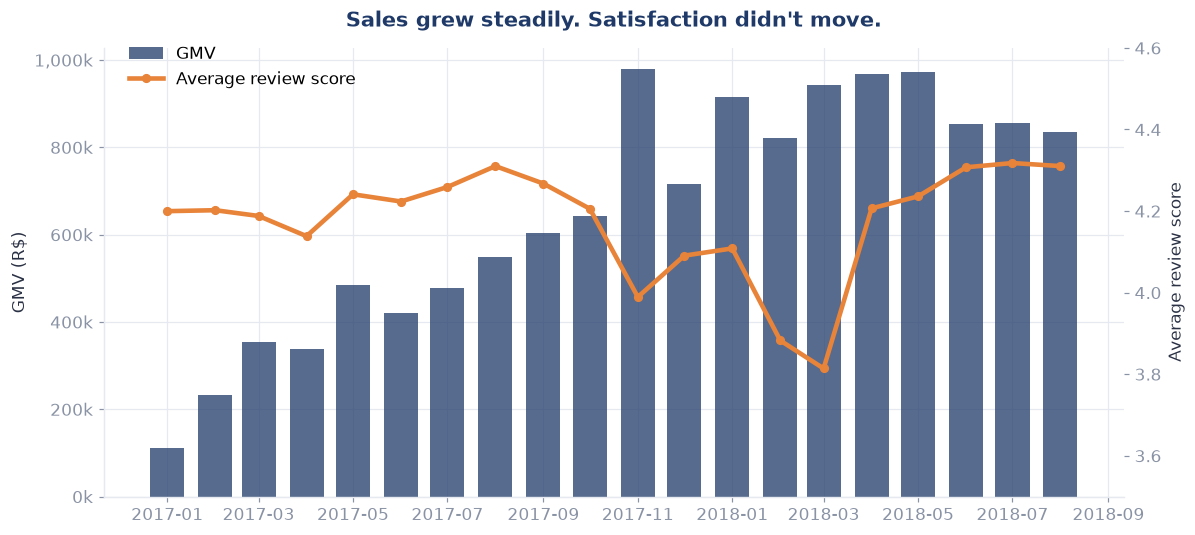

In [ ]:
monthly = base.groupby("month").agg(
    gmv=("item_total", "sum"),
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    bad_rate=("is_bad", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(monthly.month, monthly.gmv, width=22, color=NAVY, alpha=0.75, label="GMV")
ax1.set_ylabel("GMV (R$)")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))

ax2 = ax1.twinx()
ax2.plot(monthly.month, monthly.avg_score, color=AMBER, lw=3,
         marker="o", ms=5, label="Average review score")
ax2.set_ylim(3.5, 4.6)
ax2.set_ylabel("Average review score")
ax2.grid(False)

ax1.set_title("Sales grew steadily. Satisfaction didn't move.")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.93))
plt.tight_layout(); plt.show()


Sales climbed roughly tenfold across the period and the average score sat around
4.16 the whole way. Taken at face value, there's no problem here at all.

A national average across 27 states and 70 product categories is an enormously
blunt instrument. A flat average is exactly what you'd see if one region were
deteriorating badly while a bigger one stayed healthy. São Paulo is 42% of
orders on its own, so it can hold the mean up while everything else slides.

The answer to question one is: not visibly, and that's precisely why it is worth
looking harder. The analysis therefore shifts from the overall mean to where the
bad reviews actually cluster.


# 5. What makes someone leave a one-star review?

The shape of the outcome determines how it should be modelled.


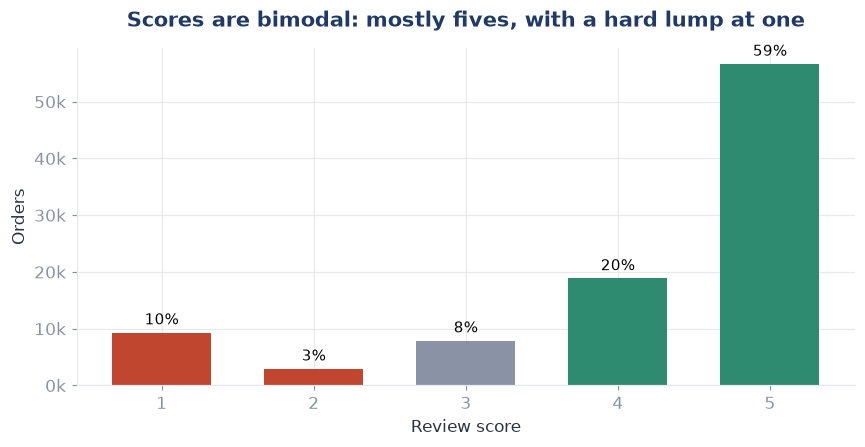

Mean score: 4.16
Share 1-2 stars: 12.8%


In [15]:
dist = base.review_score.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [RED, RED, GREY, GREEN, GREEN]
ax.bar(dist.index, dist.values, color=colors, width=0.65)
for x, v in dist.items():
    ax.annotate(f"{v/dist.sum():.0%}", (x, v), ha="center", va="bottom",
                xytext=(0, 3), textcoords="offset points", fontsize=10)
ax.set_xlabel("Review score"); ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
ax.set_title("Scores are bimodal: mostly fives, with a hard lump at one")
plt.tight_layout(); plt.show()

print(f"Mean score: {base.review_score.mean():.2f}")
print(f"Share 1-2 stars: {base.is_bad.mean():.1%}")


This shape changes how the rest of the analysis should be approached.

57% of reviews are five stars and 12% are one star. Very little sits in the
middle. So the mean of 4.16 describes a region where almost no actual review
falls. It's the average of a crowd standing at two ends of a room.

That makes predicting the average score close to meaningless. Operationally, the
useful outcome is whether an order produces a **detractor**: someone who leaves
one or two stars. This binary outcome is well-defined and maps onto an action.


In [16]:
comparison = base.groupby("is_late").agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    one_star=("review_score", lambda s: (s == 1).mean()),
    bad_rate=("is_bad", "mean"),
).rename(index={0.0: "On time", 1.0: "Late"})

print(comparison.round(3))


         orders  avg_score  one_star  bad_rate
is_late                                       
On time   87902      4.295     0.066     0.092
Late       7658      2.568     0.461     0.540


There it is. On-time orders average 4.30 stars. Late ones average 2.57.

That's not a nudge, it's a collapse: 1.7 stars, from a single binary. Nothing
else tested in this dataset comes close to that effect size. 46% of late orders
get a *one-star* review, against 7% of on-time ones.

The next question is whether the effect is gradual, with every extra day costing
a little, or whether it follows a different shape.


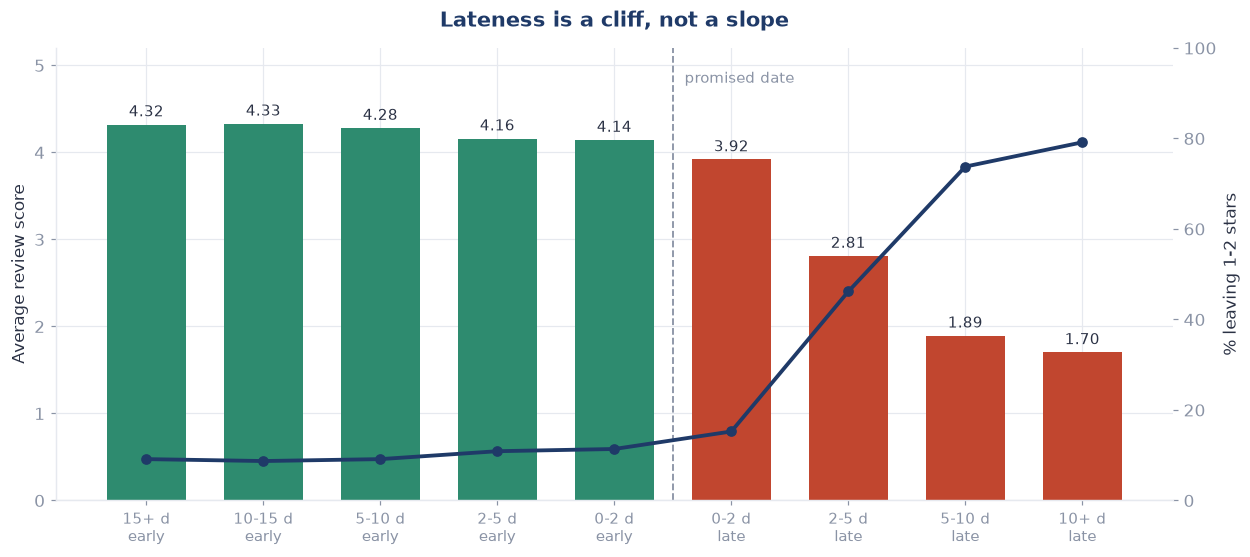

  delay_bucket  orders  avg_score  bad_rate
  15+ d\nearly   29209      4.320     0.091
10-15 d\nearly   27443      4.328     0.087
 5-10 d\nearly   22437      4.279     0.091
  2-5 d\nearly    5824      4.158     0.109
  0-2 d\nearly    2989      4.142     0.114
   0-2 d\nlate    2099      3.918     0.152
   2-5 d\nlate    1468      2.809     0.462
  5-10 d\nlate    1861      1.893     0.738
   10+ d\nlate    2230      1.702     0.791


In [17]:
bins   = [-1e4, -15, -10, -5, -2, 0, 2, 5, 10, 1e4]
labels = ["15+ d\nearly", "10-15 d\nearly", "5-10 d\nearly", "2-5 d\nearly",
          "0-2 d\nearly", "0-2 d\nlate", "2-5 d\nlate", "5-10 d\nlate",
          "10+ d\nlate"]
base["delay_bucket"] = pd.cut(base.delay_days, bins=bins, labels=labels)

curve = base.groupby("delay_bucket", observed=True).agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    bad_rate=("is_bad", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(11.5, 5.2))
bar_colors = [GREEN if "early" in str(b) else RED for b in curve.delay_bucket]
ax1.bar(range(len(curve)), curve.avg_score, color=bar_colors, width=0.68)
label_bars(ax1)
ax1.set_xticks(range(len(curve)))
ax1.set_xticklabels(curve.delay_bucket, fontsize=9.5)
ax1.set_ylim(0, 5.2); ax1.set_ylabel("Average review score")

ax2 = ax1.twinx()
ax2.plot(range(len(curve)), curve.bad_rate * 100, color=NAVY, lw=2.5,
         marker="o", ms=6)
ax2.set_ylabel("% leaving 1-2 stars"); ax2.set_ylim(0, 100); ax2.grid(False)

ax1.axvline(4.5, color=GREY, ls="--", lw=1.2)
ax1.text(4.6, 4.8, "promised date", color=GREY, fontsize=10)
ax1.set_title("Lateness is a cliff, not a slope")
plt.tight_layout(); plt.show()

print(curve.round(3).to_string(index=False))


This is the most useful chart in the notebook, and it says two separate things.

**Look at the left half.** Delivering fifteen days early (4.32) scores no better
than delivering two days early (4.14). Once an order is comfortably inside the
promise, being faster buys almost nothing. Any investment aimed at making
already-fast deliveries faster is wasted.

**Now the right half.** Two days late is survivable at 3.92. Five to ten days
late collapses to 1.89. The damage is concentrated entirely in the tail.

Together those findings point somewhere quite specific: the goal isn't to reduce
average delivery time. It is to eliminate the worst outcomes. A programme that
shaved a day off every delivery in the country would achieve less than one that
fixed the slowest 5%.

That reframing matters more than the individual numbers because it changes what
should be funded.


# 6. Whose delay is it?

The brief talks about slow sellers. That's the intuitive culprit: a seller sits
on an order for a week and the customer suffers. The data can test that claim by
splitting the journey into its stages.


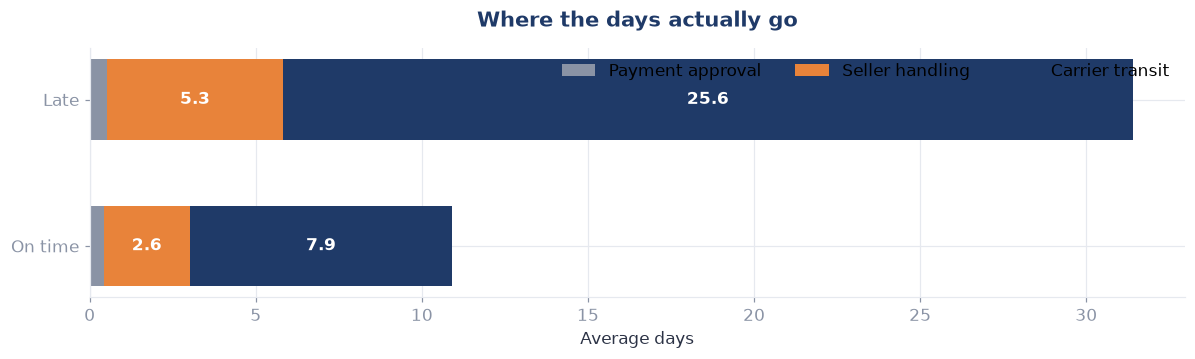

         Payment approval  Seller handling  Carrier transit
group                                                      
On time              0.42             2.60             7.89
Late                 0.51             5.31            25.57

Correlation with review score:
review_score     1.000
handling_days   -0.159
transit_days    -0.300
delivery_days   -0.334
Name: review_score, dtype: float64


In [18]:
stages = []
for label, sub in [("On time", base[base.is_late == 0]),
                   ("Late",    base[base.is_late == 1])]:
    stages.append({
        "group": label,
        "Payment approval": sub.approval_days.mean(),
        "Seller handling":  sub.handling_days.mean(),
        "Carrier transit":  sub.transit_days.mean(),
    })
stages = pd.DataFrame(stages).set_index("group")

fig, ax = plt.subplots(figsize=(11, 3.4))
left = np.zeros(len(stages))
for col, color in [("Payment approval", GREY), ("Seller handling", AMBER),
                   ("Carrier transit", NAVY)]:
    ax.barh(stages.index, stages[col], left=left, color=color, label=col,
            height=0.55)
    for i, (v, l) in enumerate(zip(stages[col], left)):
        if v > 1:
            ax.text(l + v/2, i, f"{v:.1f}", ha="center", va="center",
                    color="white", fontsize=11, fontweight="bold")
    left += stages[col].values

ax.set_xlabel("Average days"); ax.legend(ncol=3, loc="upper right")
ax.set_title("Where the days actually go")
plt.tight_layout(); plt.show()

print(stages.round(2))
print("\nCorrelation with review score:")
print(base[["review_score", "handling_days", "transit_days",
            "delivery_days"]].corr()["review_score"].round(3))


Sellers hand parcels to the carrier in **2.8 days** on average. The carrier then
holds them for **9.3 days**. On late orders the seller adds 5.3 days and the
carrier adds 25.6.

The correlations point the same way: -0.16 for seller handling against -0.30
for carrier transit. The carrier holds the parcel more than three times as long
and matters about twice as much to the outcome.

So the lever in the brief, cracking down on slow sellers, is aimed at the
smaller half of the problem. It is not useless, but it is not the main one. The
distinction matters because coaching sellers and negotiating with carriers are
completely different programmes.

This conclusion is checked independently in section 9 using review text.


# 7. Geography

Brazil is large, so distance is expected to explain much of the transit story.


In [19]:
geo = raw["geolocation"]
geo = geo[(geo.geolocation_lat.between(-34, 5.3))
          & (geo.geolocation_lng.between(-74, -34.8))]
centroid = geo.groupby("geolocation_zip_code_prefix")[
    ["geolocation_lat", "geolocation_lng"]].median()

print(f"Geolocation rows: {len(raw['geolocation']):,} "
      f"-> {len(centroid):,} zip prefixes")
print(f"Dropped {len(raw['geolocation']) - len(geo):,} points outside Brazil")


Geolocation rows: 1,000,163 -> 19,010 zip prefixes
Dropped 47 points outside Brazil


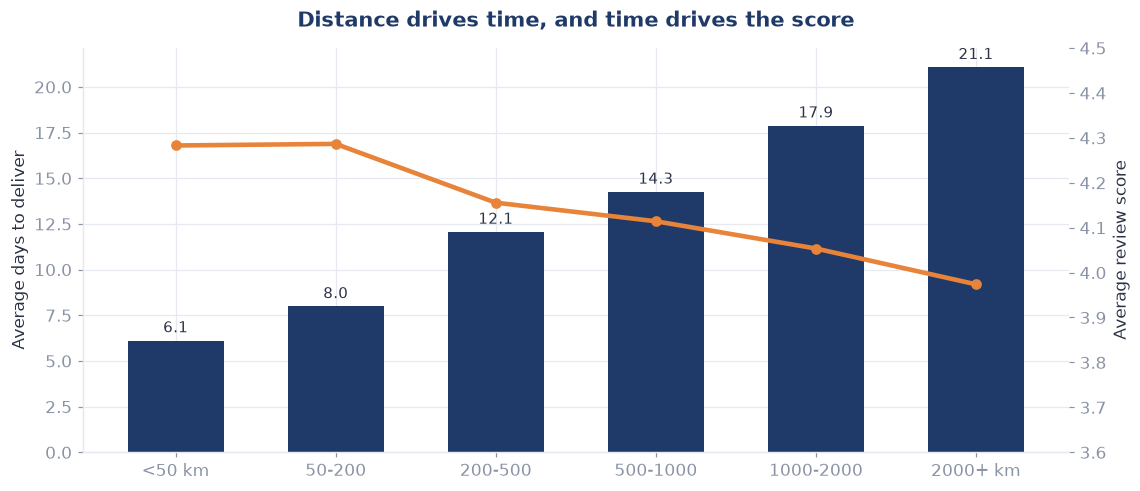

distance_band  orders  delivery_days  avg_score  late_rate
       <50 km   11644          6.117      4.283      0.064
       50-200   12793          7.986      4.286      0.061
      200-500   29947         12.062      4.156      0.073
     500-1000   25524         14.253      4.114      0.083
    1000-2000    9638         17.878      4.054      0.105
     2000+ km    5538         21.078      3.974      0.135


In [20]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlam = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


# Attach coordinates for both ends of each order.
cz = raw["customers"].set_index("customer_id").customer_zip_code_prefix
sz = raw["sellers"].set_index("seller_id").seller_zip_code_prefix

base["cust_zip"] = base.customer_id.map(cz)
base["sell_zip"] = base.main_seller.map(sz)
for side, src in [("cust", "cust_zip"), ("sell", "sell_zip")]:
    base[f"{side}_lat"] = base[src].map(centroid.geolocation_lat)
    base[f"{side}_lng"] = base[src].map(centroid.geolocation_lng)

base["distance_km"] = haversine(base.sell_lat, base.sell_lng,
                                base.cust_lat, base.cust_lng)
base["distance_band"] = pd.cut(
    base.distance_km, [-1, 50, 200, 500, 1000, 2000, 1e5],
    labels=["<50 km", "50-200", "200-500", "500-1000", "1000-2000", "2000+ km"])

dist = base.groupby("distance_band", observed=True).agg(
    orders=("order_id", "size"),
    delivery_days=("delivery_days", "mean"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10.5, 4.6))
ax1.bar(range(len(dist)), dist.delivery_days, color=NAVY, width=0.6)
label_bars(ax1, "{:.1f}")
ax1.set_xticks(range(len(dist))); ax1.set_xticklabels(dist.distance_band)
ax1.set_ylabel("Average days to deliver")

ax2 = ax1.twinx()
ax2.plot(range(len(dist)), dist.avg_score, color=AMBER, lw=3, marker="o", ms=6)
ax2.set_ylabel("Average review score"); ax2.set_ylim(3.6, 4.5); ax2.grid(False)
ax1.set_title("Distance drives time, and time drives the score")
plt.tight_layout(); plt.show()

print(dist.round(3).to_string(index=False))


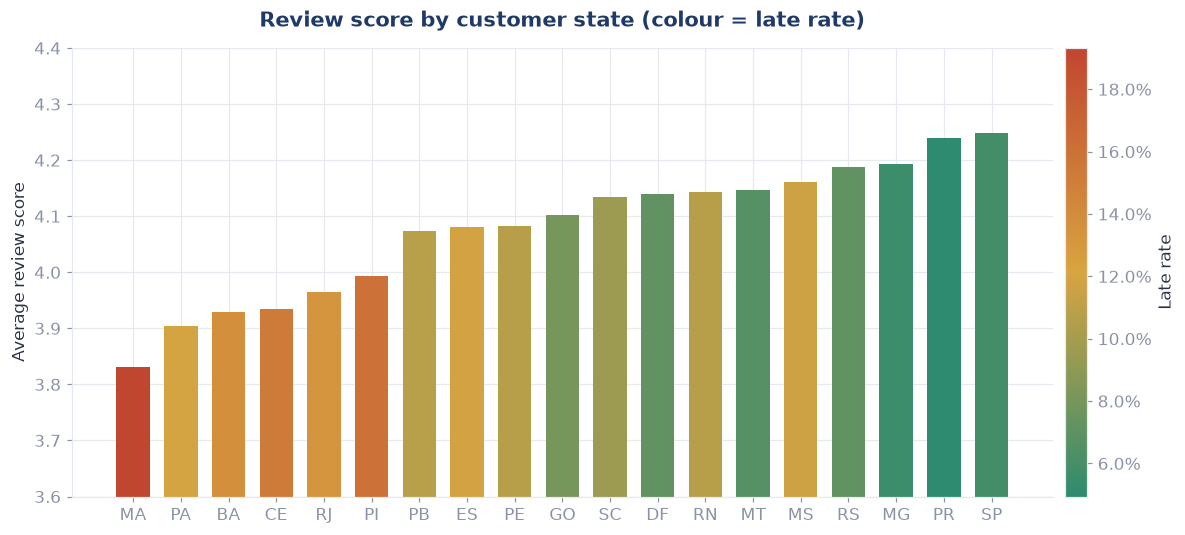

customer_state  orders  avg_score  late_rate  delivery_days
            MA     709      3.831      0.193         21.464
            PA     929      3.904      0.119         23.625
            BA    3226      3.930      0.137         19.244
            CE    1267      3.935      0.153         21.177
            RJ   12172      3.965      0.133         15.229
...
customer_state  orders  avg_score  late_rate  delivery_days
            MG   11251      4.194      0.055         11.963
            PR    4880      4.240      0.049         11.954
            SP   40171      4.248      0.058          8.723


In [21]:
state = base.groupby("customer_state").agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    delivery_days=("delivery_days", "mean"),
).reset_index()
state = state[state.orders >= 400].sort_values("avg_score")

fig, ax = plt.subplots(figsize=(11.5, 5))
norm = plt.Normalize(state.late_rate.min(), state.late_rate.max())
cmap = sns.blend_palette([GREEN, "#d9a441", RED], as_cmap=True)
bars = ax.bar(state.customer_state, state.avg_score,
              color=[cmap(norm(v)) for v in state.late_rate], width=0.7)
ax.set_ylim(3.6, 4.4); ax.set_ylabel("Average review score")
ax.set_title("Review score by customer state (colour = late rate)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.01)
cb.set_label("Late rate"); cb.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()

print(state.head(5).round(3).to_string(index=False))
print("...")
print(state.tail(3).round(3).to_string(index=False))


The spread is wider than expected. Maranhão averages 3.84 with a 17% late rate
and 21 days to deliver. São Paulo averages 4.25 with 4% late and under 9 days.
Same marketplace, same promise, completely different experience.

**Rio de Janeiro** is the priority for escalation. It doesn't look dramatic on
this chart: 3.96 is mid-table. But it's the second-largest market in the
country and it's running triple São Paulo's late rate. Volume times a bad rate
is where the real damage is, and Rio has both. Maranhão is worse per order but
there are only 716 of them.

This volume-severity logic is formalised in section 10.


# 8. Split shipments

Basket size was evaluated as a possible driver of satisfaction. The result is
material and warrants separate treatment.


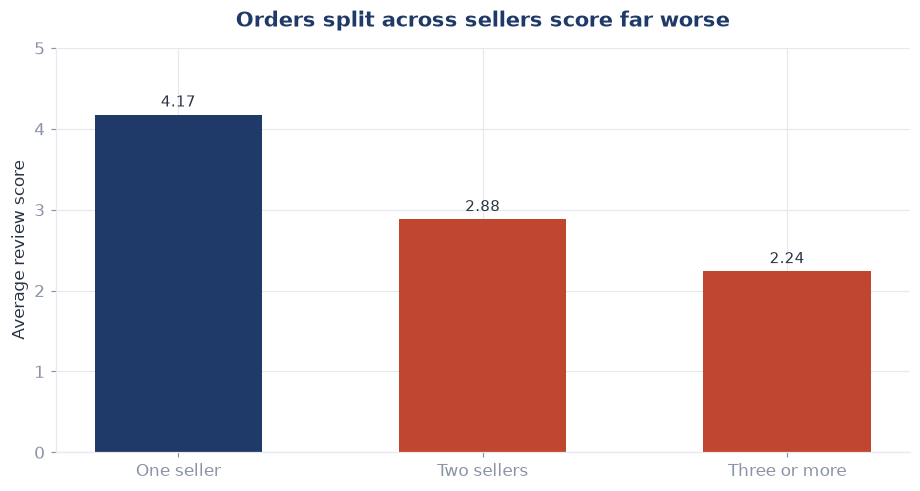

               orders  avg_score  bad_rate  late_rate  delivery_days
One seller      94302      4.174     0.123      0.081         12.543
Two sellers      1199      2.881     0.466      0.014          9.158
Three or more      59      2.237     0.644      0.000          8.380

Share of orders that are split: 1.32%


In [22]:
split = base.groupby(base.n_sellers.clip(upper=3)).agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    bad_rate=("is_bad", "mean"),
    late_rate=("is_late", "mean"),
    delivery_days=("delivery_days", "mean"),
)
split.index = ["One seller", "Two sellers", "Three or more"]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(split.index, split.avg_score, color=[NAVY, RED, RED], width=0.55)
label_bars(ax)
ax.set_ylim(0, 5); ax.set_ylabel("Average review score")
ax.set_title("Orders split across sellers score far worse")
plt.tight_layout(); plt.show()

print(split.round(3))
print(f"\nShare of orders that are split: {base.multi_seller.mean():.2%}")


An order from one seller averages 4.17. Split it across two and it drops to
2.89. Three or more and it's 2.24.

The mechanism makes sense once the order is viewed as a basket. It arrives in
pieces over several days, and the customer waits for the slowest parcel before
reviewing the whole order. One slow seller poisons the entire basket.

This is the most concentrated finding in the notebook: it costs 1.3 stars and
affects only **1.3% of orders**. It needs either consolidated fulfilment or a
clearer checkout that sets expectations per parcel, so the customer mentally
scores three deliveries instead of one bad one.


# 9. Checking the delivery story a different way

Section 6 identified the carrier as the main problem. That conclusion drives an
expensive recommendation, so it needs evidence from a source other than the
delivery timestamps.

41% of reviews carry written comments. They're in Portuguese. The comments
provide an independent witness.


Negative comments: 9,185
Positive comments: 26,133


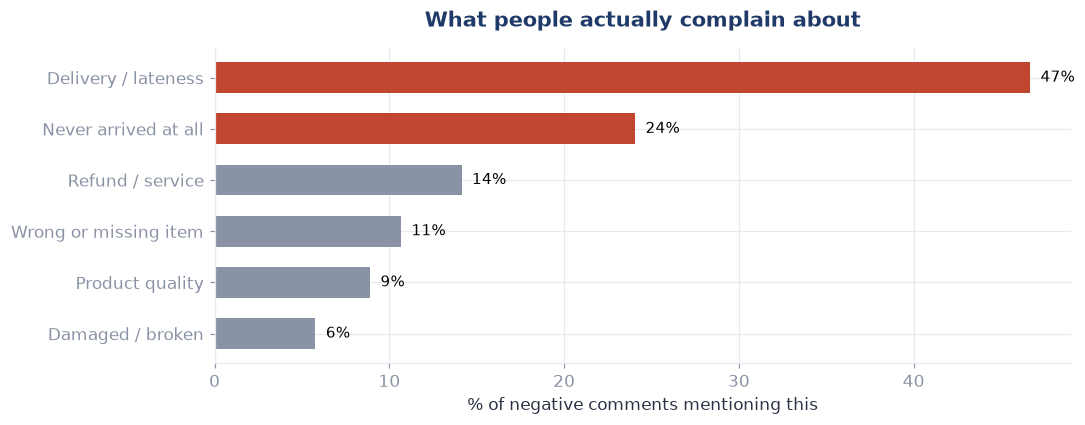

In [23]:
commented = base[base.review_comment_message.notna()]
neg = commented[commented.review_score <= 2].review_comment_message.str.lower()
pos = commented[commented.review_score >= 4].review_comment_message.str.lower()

print(f"Negative comments: {len(neg):,}")
print(f"Positive comments: {len(pos):,}")

themes = {
    "Delivery / lateness":   r"prazo|entrega|entregue|chegou|atras|aguard|esper|correios|demor",
    "Never arrived at all":  r"n[ãa]o receb|n[ãa]o chegou|n[ãa]o foi entregue|extrav",
    "Refund / service":      r"reembols|devolv|devolu|cancel|contato|resposta|atendimento",
    "Wrong or missing item": r"errad|diferente|faltou|apenas um|outro produto",
    "Product quality":       r"qualidade|p[ée]ssim|ruim|horr[íi]vel|fr[áa]gil|material",
    "Damaged / broken":      r"quebrad|danific|defeito|estragad|amassad",
}

rows = [{"theme": t, "share": neg.str.contains(p, regex=True).mean()}
        for t, p in themes.items()]
theme_df = pd.DataFrame(rows).sort_values("share")

fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if "Delivery" in t or "Never" in t else GREY
          for t in theme_df.theme]
ax.barh(theme_df.theme, theme_df.share * 100, color=colors, height=0.6)
for i, v in enumerate(theme_df.share * 100):
    ax.text(v + 0.6, i, f"{v:.0f}%", va="center", fontsize=10)
ax.set_xlabel("% of negative comments mentioning this")
ax.set_title("What people actually complain about")
plt.tight_layout(); plt.show()


48% of negative comments mention delivery. 26% say the order never turned up at
all. Product quality, the factor most likely to be assumed as the main driver
of a one-star review, is 9%.

Two independent sources, structured timestamps and unstructured Portuguese
text, point at the same conclusion. A logistics investment is supported.

One point remains separate: **16% of complaints are about refunds and service
response.** No amount of faster shipping touches those. It is a smaller problem
than delivery but belongs to a different team.


# 10. Turning this into something a manager can act on

The analysis compares segments that differ in both size and severity. Maranhão
is bad but small, Rio is mediocre but huge. The following metric ranks which
segments should be addressed first.

For any segment:

```
excess detractors = orders x (segment bad-rate - marketplace bad-rate)
```

Plain English: **how many one- and two-star reviews would vanish if this segment
merely behaved like the marketplace average?** A positive number means a segment
is destroying more goodwill than its size warrants.

To price it, excess detractors are multiplied by the average order value. This
rests on the observed repeat-purchase rate:


In [24]:
repeat = raw["customers"].groupby("customer_unique_id").size()
print(f"Customers who ever ordered twice: {(repeat > 1).mean():.1%}")


Customers who ever ordered twice: 3.1%


Only 3.1% of customers ever come back.

In a market with essentially no repeat purchase, an unhappy customer isn't
someone to win back with a voucher. They're already gone, and whatever was spent
acquiring them bought exactly one order. So valuing a detractor at one average
order value is a reasonable floor. It ignores word of mouth and the orders they
now never place, so the true cost is higher, but a floor is defensible and
conservative.


In [25]:
BASELINE = base.is_bad.mean()
print(f"Marketplace detractor rate: {BASELINE:.2%}")


def risk_table(frame, key, min_orders=300):
    g = frame.groupby(key, observed=True).agg(
        orders=("order_id", "size"),
        avg_score=("review_score", "mean"),
        bad_rate=("is_bad", "mean"),
        late_rate=("is_late", "mean"),
        delivery_days=("delivery_days", "mean"),
        gmv=("item_total", "sum"),
    ).reset_index()
    g = g[g.orders >= min_orders]
    g["excess_detractors"] = g.orders * (g.bad_rate - BASELINE)
    g["exposure"] = g.excess_detractors.clip(lower=0) * (g.gmv / g.orders)
    return g.sort_values("exposure", ascending=False)


cat_risk = risk_table(base, "main_category", min_orders=500)
print(cat_risk.head(8)[["main_category", "orders", "avg_score", "late_rate",
                        "excess_detractors", "exposure"]].round(2).to_string(index=False))


Marketplace detractor rate: 12.79%
        main_category  orders  avg_score  late_rate  excess_detractors  exposure
       bed_bath_table    9086       4.01       0.09             272.10  30360.56
     office_furniture    1236       3.65       0.09             111.94  24011.24
computers_accessories    6468       4.08       0.08             108.89  14879.32
      furniture_decor    6095       4.08       0.09             124.58  14269.61
        watches_gifts    5432       4.12       0.08              48.37  10304.33
              unknown    1347       4.04       0.09              49.75   6297.27
                 baby    2730       4.12       0.09              25.89   3761.77
            telephony    4042       4.06       0.09              46.12   3504.43


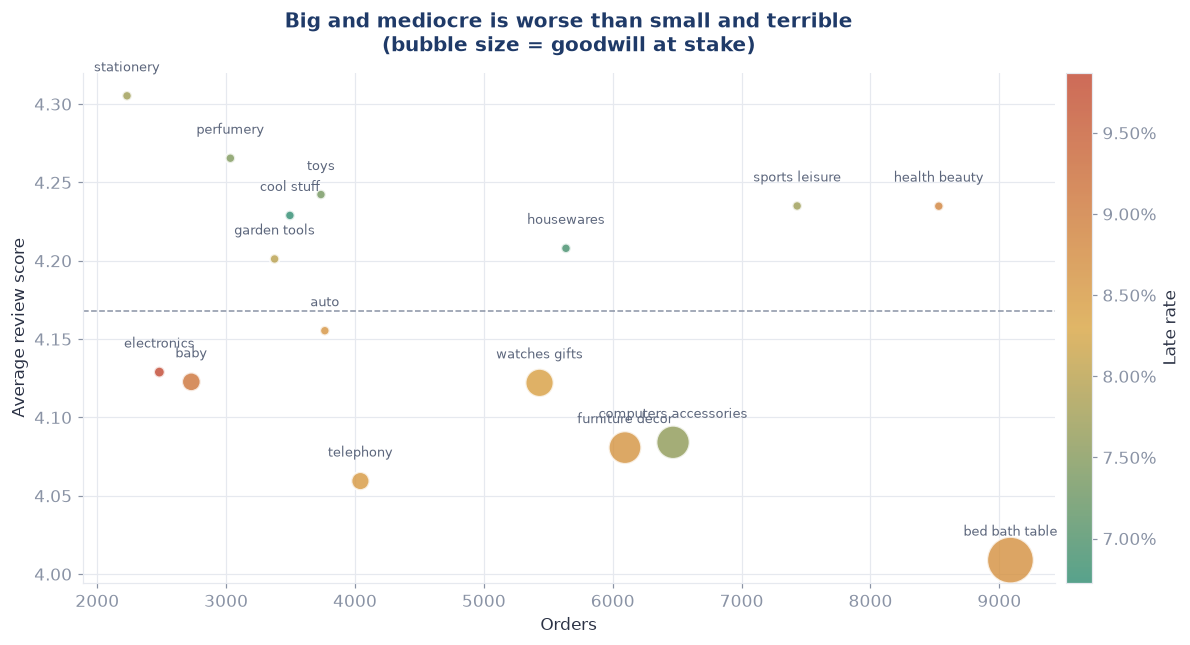

In [26]:
top = cat_risk.nlargest(16, "orders")

fig, ax = plt.subplots(figsize=(11.5, 6))
sizes = (top.exposure / top.exposure.max() * 900) + 40
sc = ax.scatter(top.orders, top.avg_score, s=sizes, c=top.late_rate,
                cmap=sns.blend_palette([GREEN, "#d9a441", RED], as_cmap=True),
                alpha=0.8, edgecolor="white", linewidth=1.5)

for _, r in top.iterrows():
    ax.annotate(r.main_category.replace("_", " "), (r.orders, r.avg_score),
                fontsize=8.5, color="#5c667c", ha="center",
                xytext=(0, 16), textcoords="offset points")

ax.axhline(top.avg_score.mean(), color=GREY, ls="--", lw=1)
ax.set_xlabel("Orders"); ax.set_ylabel("Average review score")
ax.set_title("Big and mediocre is worse than small and terrible\n"
             "(bubble size = goodwill at stake)", fontsize=13)
cb = plt.colorbar(sc, ax=ax, pad=0.01); cb.set_label("Late rate")
cb.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()


The bottom-right of that chart is the danger zone: high volume, below-average
score. Bed/bath/table sits there and it's the single largest exposure in the
catalogue, not because it's the worst rated, but because it's large, slightly
bad and slow all at once.

Office furniture is the worst by score (3.65) but it's small enough that fixing
it moves less goodwill than fixing bed/bath/table would.


# 11. Sellers: a verdict, not a score

The brief's fear is that removing weak sellers shrinks the catalogue and stalls
growth. This can be tested by scoring every seller on two axes: product quality
and on-time delivery. The analysis measures how much revenue is tied up in the
genuinely bad ones.

Only sellers with 30+ orders are judged. Below that, one unlucky customer can
swing the average and lead to delisting based on noise.


In [27]:
MIN_ORDERS, BAD_SCORE, BAD_LATE = 30, 3.5, 0.10

sellers = base.groupby("main_seller").agg(
    orders=("order_id", "size"),
    avg_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
    handling_days=("handling_days", "mean"),
    gmv=("item_total", "sum"),
).reset_index()


def verdict(r):
    if r.orders < MIN_ORDERS:
        return "Too small to judge"
    poor_product  = r.avg_score < BAD_SCORE
    poor_delivery = r.late_rate > BAD_LATE
    if poor_product and poor_delivery:
        return "Remove"
    if poor_product:
        return "Coach: product"
    if poor_delivery:
        return "Coach: fulfilment"
    return "Invest"


sellers["verdict"] = sellers.apply(verdict, axis=1)

summary = sellers.groupby("verdict").agg(
    sellers=("main_seller", "size"),
    gmv=("gmv", "sum"),
)
summary["gmv_share"] = summary.gmv / sellers.gmv.sum()
print(summary.sort_values("gmv_share", ascending=False).round(4))


                    sellers         gmv  gmv_share
verdict                                           
Invest                  439  6742203.79     0.5159
Too small to judge     2316  3022162.82     0.2312
Coach: fulfilment       156  2892404.10     0.2213
Coach: product            4   231175.65     0.0177
Remove                   16   181023.96     0.0139


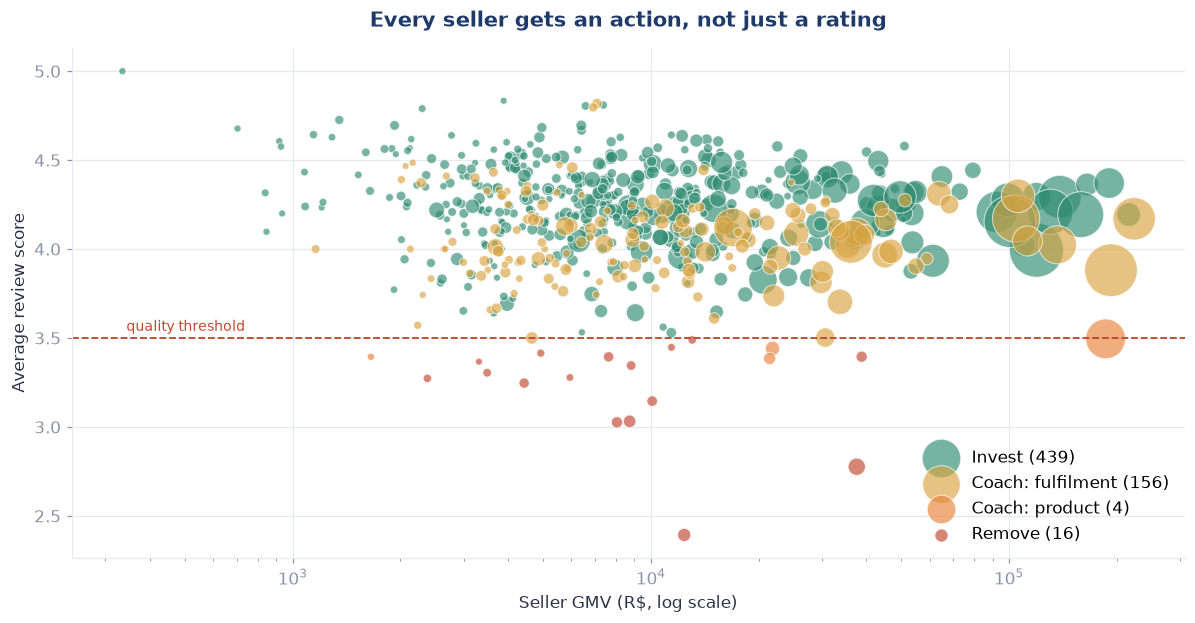

In [28]:
judged = sellers[sellers.orders >= MIN_ORDERS]
palette = {"Invest": GREEN, "Coach: fulfilment": "#d9a441",
           "Coach: product": AMBER, "Remove": RED}

fig, ax = plt.subplots(figsize=(11, 5.8))
for v, color in palette.items():
    s = judged[judged.verdict == v]
    ax.scatter(s.gmv, s.avg_score, s=s.orders * 0.7, c=color, alpha=0.65,
               edgecolor="white", linewidth=0.7, label=f"{v} ({len(s)})")

ax.set_xscale("log")
ax.axhline(BAD_SCORE, color=RED, ls="--", lw=1.2)
ax.text(judged.gmv.min(), BAD_SCORE + 0.04, " quality threshold",
        color=RED, fontsize=9)
ax.set_xlabel("Seller GMV (R$, log scale)")
ax.set_ylabel("Average review score")
ax.set_title("Every seller gets an action, not just a rating")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


**16 sellers** fail on both counts. Between them they hold **1.4% of GMV.**

The catalogue-shrinkage fear turns out to be almost entirely unfounded at the
irredeemable end. You could delist every one of them tomorrow and give up about
one part in seventy of revenue.

But the more interesting group is the 156 sellers who deliver late while selling
perfectly good products. They're 22% of GMV. Delisting those would be
self-harm, and given section 6, a lot of their lateness isn't even theirs. They
need pickup scheduling and carrier support, not a warning letter.

So the recommendation splits: remove 16, coach 156. That's a much more precise
answer than "crack down on slow sellers".


# 12. Can we see a bad review coming?

This model is used to rank drivers and determine whether risk can be flagged early
enough for intervention. Prediction is not the deliverable.

Two rules govern the evaluation:

**Split by time, not at random.** Train on the earlier orders, test on the later
ones. A random split lets the model learn from future orders to predict past
ones, which inflates the score and would not survive scrutiny.

**Seller history must be strictly prior.** A seller's lifetime average score
cannot be used to predict an order that is part of that average. It is computed
as an expanding mean, shifted by one.


In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import OrdinalEncoder

m = base.sort_values("order_purchase_timestamp").copy()
m = m[m.is_bad.notna()]

g = m.groupby("main_seller")
m["seller_prior_orders"] = g.cumcount()
m["seller_prior_score"]  = g.review_score.apply(
    lambda s: s.shift().expanding().mean()).reset_index(level=0, drop=True)
m["seller_prior_late"]   = g.is_late.apply(
    lambda s: s.shift().expanding().mean()).reset_index(level=0, drop=True)

CAT = ["main_category", "customer_state", "seller_state", "payment_type"]
NUM = ["item_total", "freight_total", "freight_ratio", "n_items", "n_sellers",
       "installments", "distance_km", "promised_days",
       "seller_prior_orders", "seller_prior_score", "seller_prior_late"]

cut = m.order_purchase_timestamp.quantile(0.75)
train, test = m[m.order_purchase_timestamp < cut], m[m.order_purchase_timestamp >= cut]
print(f"Train: {len(train):,} orders (before {cut:%Y-%m-%d})")
print(f"Test:  {len(test):,} orders")


Train: 71,670 orders (before 2018-05-06)
Test:  23,890 orders


In [30]:
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1,
                     encoded_missing_value=-1)


def prep(frame, fit=False):
    cats = enc.fit_transform(frame[CAT]) if fit else enc.transform(frame[CAT])
    return np.hstack([cats, frame[NUM].to_numpy(dtype=float)])


Xtr, ytr = prep(train, fit=True), train.is_bad.astype(int)
Xte, yte = prep(test), test.is_bad.astype(int)

clf = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.06, min_samples_leaf=40,
    categorical_features=list(range(len(CAT))), random_state=42)
clf.fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]

print(f"ROC AUC            {roc_auc_score(yte, p):.3f}")
print(f"PR AUC             {average_precision_score(yte, p):.3f}"
      f"   (baseline {yte.mean():.3f})")

order = np.argsort(-p)
for frac in (0.05, 0.10, 0.20):
    k = int(len(p) * frac)
    caught = yte.iloc[order[:k]].sum() / yte.sum()
    print(f"Riskiest {frac:.0%} of orders contain {caught:.1%} of detractors"
          f"   ({caught/frac:.1f}x lift)")


ROC AUC            0.631
PR AUC             0.181   (baseline 0.100)
Riskiest 5% of orders contain 13.8% of detractors   (2.8x lift)
Riskiest 10% of orders contain 22.4% of detractors   (2.2x lift)
Riskiest 20% of orders contain 35.6% of detractors   (1.8x lift)


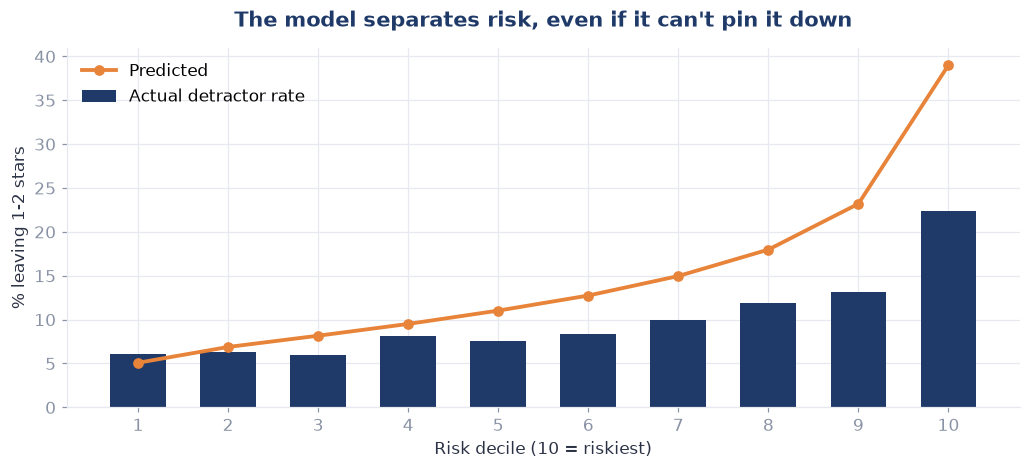

In [31]:
deciles = (test.assign(risk=p, decile=pd.qcut(p, 10, labels=False))
           .groupby("decile").agg(actual=("is_bad", "mean"),
                                  predicted=("risk", "mean"),
                                  orders=("order_id", "size")))

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(deciles.index + 1, deciles.actual * 100, color=NAVY, width=0.62,
       label="Actual detractor rate")
ax.plot(deciles.index + 1, deciles.predicted * 100, color=AMBER, lw=2.5,
        marker="o", ms=6, label="Predicted")
ax.set_xticks(range(1, 11))
ax.set_xlabel("Risk decile (10 = riskiest)")
ax.set_ylabel("% leaving 1-2 stars")
ax.legend(); ax.set_title("The model separates risk, even if it can't pin it down")
plt.tight_layout(); plt.show()


AUC of 0.64 using only what's knowable at checkout.

This is a modest number, but it is the appropriate level of performance for the
available information. A model claiming 0.9 here would likely be leaking
information it should not have. Most of what makes a customer angry, a carrier
losing the parcel, a defective unit, the wrong item shipped, genuinely has not
happened yet when the order is placed. It cannot be predicted because it is not
determined yet.

The model separates risk. The riskiest 10% of orders contain 23% of eventual
detractors, a bit over twice what random selection would give you. That is enough
to build an outreach queue, if operations can only review a fraction of orders.
It is *not* enough to quote a probability to anyone.

Notice too what's absent from the feature list: `delay_days`. It's the strongest
predictor in the whole dataset and it doesn't exist yet at checkout. That gap is
the central observation: the thing that determines the outcome is decided after
the order is placed, by the carrier.


# 13. What would each fix actually cost?

The final step puts numbers on the options. Rather than assuming an effect size,
the observed relationship between lateness and detractor risk is fitted from the
data, then history is replayed with each lever applied and the new count is
calculated.


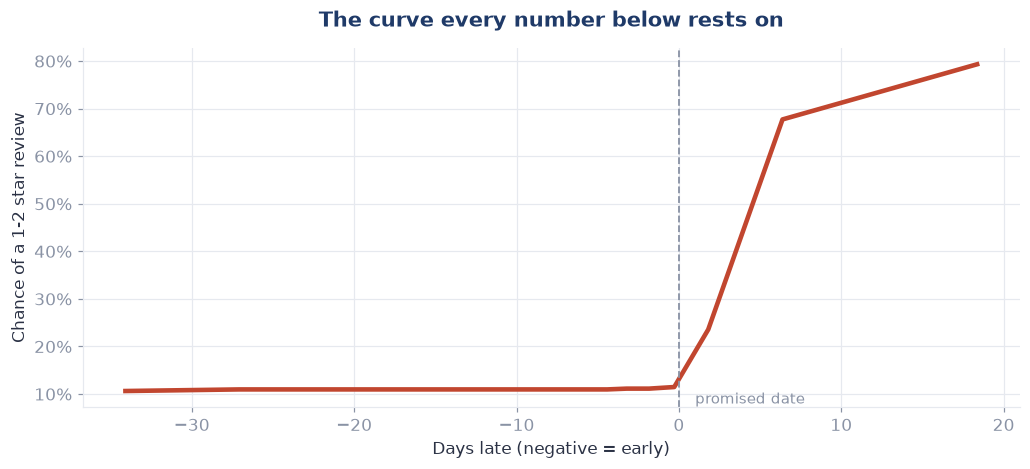

In [32]:
d = base[["delay_days", "is_bad"]].dropna().copy()
d["clipped"] = d.delay_days.clip(-40, 30)
curve_fit = (d.groupby(pd.qcut(d.clipped, 40, duplicates="drop"), observed=True)
             .agg(centre=("clipped", "mean"), rate=("is_bad", "mean"))
             .sort_values("centre").reset_index(drop=True))

# Being earlier can't increase risk, so force the curve to be monotone.
curve_fit["rate"] = np.maximum.accumulate(curve_fit.rate.values)

XP = curve_fit.centre.to_numpy(float)
FP = curve_fit.rate.to_numpy(float)


def risk_of(delay):
    return np.interp(np.clip(np.asarray(delay, float), -40, 30), XP, FP,
                     left=FP[0], right=FP[-1])


fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(XP, FP * 100, color=RED, lw=3)
ax.axvline(0, color=GREY, ls="--", lw=1.2)
ax.text(1, 8, "promised date", color=GREY, fontsize=10)
ax.set_xlabel("Days late (negative = early)")
ax.set_ylabel("Chance of a 1-2 star review")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("The curve every number below rests on")
plt.tight_layout(); plt.show()


In [33]:
def simulate(transit_cut=0.0, worst_lanes_only=True,
             promise_trim=0.0, remove_below=None):
    """Replay the order history with one or more levers applied."""
    s = base.copy()
    baseline_detractors = risk_of(s.delay_days).sum()

    saved = np.zeros(len(s))
    if transit_cut:
        if worst_lanes_only:
            lane = s.seller_state.fillna("?") + ">" + s.customer_state.fillna("?")
            rate = s.assign(l=lane).groupby("l").is_late.mean()
            target = lane.isin(rate[rate > 0.10].index).to_numpy()
        else:
            target = np.ones(len(s), bool)
        saved = np.where(target, s.transit_days.fillna(0).clip(lower=0)
                         * transit_cut, 0.0)

    new_delay = s.delay_days.to_numpy(float) - saved + promise_trim
    s["new_risk"] = risk_of(new_delay)
    s["new_late"] = new_delay > 0

    gmv_lost = 0.0
    if remove_below is not None:
        perf = s.groupby("main_seller").agg(n=("order_id", "size"),
                                            sc=("review_score", "mean"))
        drop = perf[(perf.n >= 30) & (perf.sc < remove_below)].index
        gone = s.main_seller.isin(drop)
        gmv_lost = s.loc[gone, "item_total"].sum()
        s = s[~gone]

    avoided = baseline_detractors - s.new_risk.sum()
    aov = base.item_total.sum() / len(base)
    return {
        "detractors avoided": avoided,
        "late rate after": s.new_late.mean(),
        "GMV given up": gmv_lost,
        "net value": avoided * aov - gmv_lost,
    }


scenarios = {
    "Do nothing":                     dict(),
    "Fix the worst lanes (25%)":      dict(transit_cut=0.25),
    "Speed up the whole network (25%)": dict(transit_cut=0.25, worst_lanes_only=False),
    "Remove sellers below 3.5":       dict(remove_below=3.5),
    "Shorten the promise by 3 days":  dict(promise_trim=3),
}

results = pd.DataFrame({k: simulate(**v) for k, v in scenarios.items()}).T
print(results.round(1).to_string())


                                  detractors avoided  late rate after  GMV given up  net value
Do nothing                                       0.0              0.1           0.0        0.0
Fix the worst lanes (25%)                      834.3              0.1           0.0   114107.3
Speed up the whole network (25%)              1604.8              0.0           0.0   219481.7
Remove sellers below 3.5                       400.1              0.1      412199.6  -357483.6
Shorten the promise by 3 days                -1637.8              0.1           0.0  -223985.3


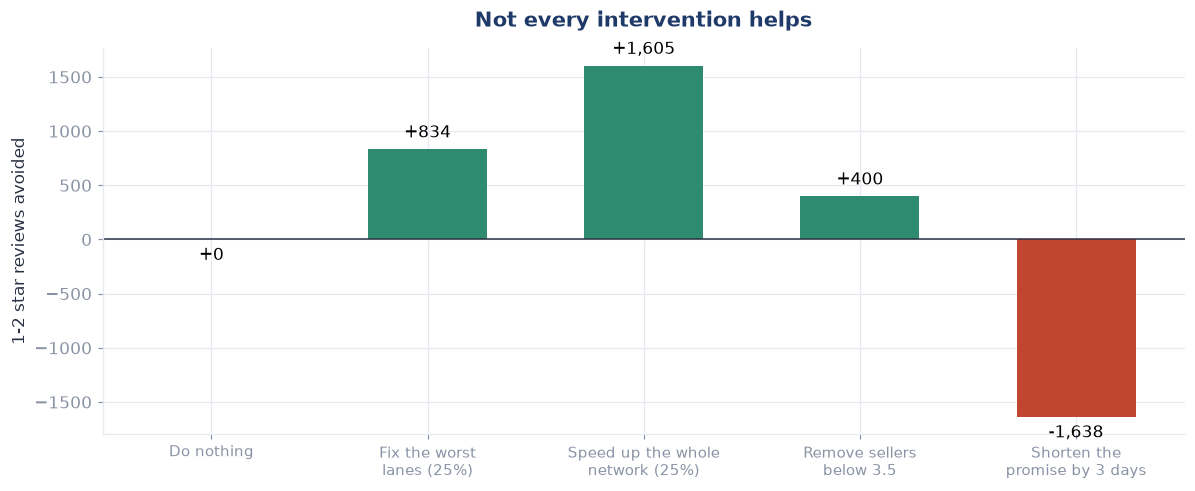

In [34]:
fig, ax = plt.subplots(figsize=(11, 4.6))
vals = results["detractors avoided"]
ax.bar(range(len(vals)), vals,
       color=[GREEN if v > 0 else RED for v in vals], width=0.55)
for i, v in enumerate(vals):
    ax.annotate(f"{v:+,.0f}", (i, v), ha="center",
                va="bottom" if v > 0 else "top",
                xytext=(0, 5 if v > 0 else -5), textcoords="offset points")
ax.axhline(0, color="#2b3245", lw=1)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([textwrap.fill(t, 18) for t in results.index], fontsize=9.5)
ax.set_ylabel("1-2 star reviews avoided")
ax.set_title("Not every intervention helps")
plt.tight_layout(); plt.show()


### The counterintuitive result

Look at the last row. **Shortening the delivery promise by three days makes
things significantly worse**: it creates about 1,600 extra detractors and
pushes the late rate from 8% to 13%.

The median order is promised in 23 days and arrives in 10, which looks like
obvious sandbagging, and tightening it may appear to build trust at checkout.
But the padding is not waste. It absorbs variance in a transit network that
sometimes takes a month. Removing it makes orders that were quietly fine become
officially late, and the cliff in section 5 does the rest.

The right sequencing follows: **buy the speed first, then spend it on a shorter
promise.** Not the other way round. The padding is a budget, and it is already
committed.

### The zero-revenue-cost intervention

Fixing the worst lanes avoids around 800 detractors and costs no revenue at all.
It is the only lever here with unambiguously positive value, and should be funded
before anything else.

Removing weak sellers is more marginal than the earlier section suggested. It
avoids 400 detractors but gives up R$412k of GMV. At one order value per lost
customer, that does not pay:


In [35]:
r = simulate(remove_below=3.5)
aov = base.item_total.sum() / len(base)
breakeven = r["GMV given up"] / (r["detractors avoided"] * aov)
print(f"Average order value:  R$ {aov:,.2f}")
print(f"Detractors avoided:   {r['detractors avoided']:,.0f}")
print(f"GMV given up:         R$ {r['GMV given up']:,.0f}")
print(f"\nDelisting pays once a lost customer is worth "
      f"more than {breakeven:.1f}x a single order.")

Average order value:  R$ 136.76
Detractors avoided:   400
GMV given up:         R$ 412,200

Delisting pays once a lost customer is worth more than 7.5x a single order.


The decision on delisting depends on the threshold: if the business believes a
lost customer is worth more than about three orders, delist. If not, coach.
The business knows its lifetime value better than this dataset does.


# 14. Where this leaves things

**On the original question:** growth and customer experience aren't opposed
across the board. They're opposed in specific, nameable places, and most of the
fixes cost far less than leadership seems to assume.

**Recommended order of action:**

1. **Fund carrier speed on the worst lanes.** The only move that improves
   experience while giving up no revenue at all. Start with the northern and
   north-eastern corridors and the São Paulo to Rio lane, which is high-volume
   and underperforming.
2. **Leave the delivery promise alone** until transit times have actually
   fallen. It protects the on-time rate, rather than padding a metric.
3. **Coach 156 sellers, remove 16.** The removal list is 1.4% of GMV. The
   coaching list is 22%, and a good part of their lateness isn't theirs.
4. **Fix split shipments.** 1.3 stars on 1.3% of orders. Cheapest thing here.
5. **Review the refund and service process.** 16% of complaints, and no
   logistics investment touches it.

**What would change the answer:**

*Lateness is treated as causal here.* The curve is steep, monotone, and the
review text says the same thing independently, which supports the conclusion,
but some of the effect could be proxying for correlated problems like poor
seller communication. The scenario numbers are magnitudes, not forecasts.

*A detractor is valued at one order.* A floor, deliberately. It ignores word of
mouth entirely, which is why the breakeven is reported rather than a verdict.

*Removed sellers are treated as lost demand.* Some would be recaptured by
competitors on the platform, so the cost of delisting shown here is a worst
case.

*The data ends in October 2018.* The absolute numbers have moved since. The
relationships between distance, lateness and satisfaction are more durable than
the levels.

**The single field with the highest value:** carrier identity. It is not in this
dataset, and it would turn "the carrier is slow" into "this carrier is slow on
this lane": the difference between an observation and something operations
can act on Monday morning.

*Next step: an interactive dashboard so the segment views can be explored rather
than read, and the scenario levers moved by the people who would fund them.*
